
# Compare XAI vs Baseline v2 Fixed

Notebook này trực quan hóa và lưu các hình so sánh giữa hai cấu hình huấn luyện:
- `output/baseline_v2_fixed_control`
- `output/xai_from_scratch_v2_fixed`

Các hình được lưu tự động vào:
- `output/compare_xai_vs_baseline_v2_fixed/figures`

Mục tiêu:
1. Tóm tắt các chỉ số phát hiện quan trọng của hai mô hình.
2. Vẽ các đường cong huấn luyện và đánh giá theo epoch.
3. Trực quan hóa riêng các chẩn đoán của nhánh saliency trong mô hình XAI-guided.
4. Ghép các artifact sẵn có như confusion matrix, results plot, và dự đoán mẫu để chèn vào báo cáo.


In [2]:

from pathlib import Path
import json
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path.cwd()
if not (ROOT / "output").exists() and (ROOT.parent / "output").exists():
    ROOT = ROOT.parent

BASELINE_DIR = Path('../..') / "output" / "baseline_v2_fixed_control"
XAI_DIR = Path('../..') / "output" / "xai_from_scratch_v2_fixed"
REPORT_DIR = Path('../..') / "output" / "compare_xai_vs_baseline_v2_fixed"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

for required in [BASELINE_DIR, XAI_DIR]:
    if not required.exists():
        raise FileNotFoundError(f"Khong tim thay thu muc artifact: {required}")

print("ROOT:", ROOT)
print("BASELINE_DIR:", BASELINE_DIR)
print("XAI_DIR:", XAI_DIR)
print("FIG_DIR:", FIG_DIR)


ROOT: /home/thanhmay/workspace/xai-driven-saliency-loss/src/notebooks
BASELINE_DIR: ../../output/baseline_v2_fixed_control
XAI_DIR: ../../output/xai_from_scratch_v2_fixed
FIG_DIR: ../../output/compare_xai_vs_baseline_v2_fixed/figures


In [3]:


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_run_from_results(run_dir: Path, run_name: str):
    history = pd.read_csv(run_dir / "results.csv")
    history.columns = [col.strip() for col in history.columns]
    best_idx = history["metrics/mAP50-95(B)"].idxmax()
    best_row = history.loc[best_idx].copy()
    final_row = history.iloc[-1].copy()
    return {
        "name": run_name,
        "dir": run_dir,
        "history": history,
        "best": best_row,
        "final": final_row,
    }


def save_figure(fig, stem: str):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png_path)
    fig.savefig(pdf_path)
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return png_path, pdf_path


baseline = load_run_from_results(BASELINE_DIR, "Baseline")
xai = load_run_from_results(XAI_DIR, "XAI-guided")

xai_summary = load_json(XAI_DIR / "summary" / "run_summary.json")
xai_best_val = load_json(XAI_DIR / "metrics" / "best_val_metrics.json")
xai_best_test = load_json(XAI_DIR / "metrics" / "best_test_metrics.json")
xai_train_history = pd.read_csv(XAI_DIR / "weights" / "train_history.csv")
xai_train_history.columns = [col.strip() for col in xai_train_history.columns]

baseline_results_plot = first_existing([BASELINE_DIR / "results.png"])
xai_results_plot = first_existing([XAI_DIR / "results.png"])

summary_rows = [
    {
        "run": "Baseline",
        "epochs_completed": int(len(baseline["history"])),
        "best_epoch": int(baseline["best"]["epoch"]),
        "best_precision": float(baseline["best"]["metrics/precision(B)"]),
        "best_recall": float(baseline["best"]["metrics/recall(B)"]),
        "best_map50": float(baseline["best"]["metrics/mAP50(B)"]),
        "best_map50_95": float(baseline["best"]["metrics/mAP50-95(B)"]),
        "final_map50_95": float(baseline["final"]["metrics/mAP50-95(B)"]),
        "total_time_hours": float(baseline["history"]["time"].iloc[-1]) / 3600.0,
    },
    {
        "run": "XAI-guided",
        "epochs_completed": int(len(xai["history"])),
        "best_epoch": int(xai["best"]["epoch"]),
        "best_precision": float(xai["best"]["metrics/precision(B)"]),
        "best_recall": float(xai["best"]["metrics/recall(B)"]),
        "best_map50": float(xai["best"]["metrics/mAP50(B)"]),
        "best_map50_95": float(xai["best"]["metrics/mAP50-95(B)"]),
        "final_map50_95": float(xai["final"]["metrics/mAP50-95(B)"]),
        "total_time_hours": float(xai["history"]["time"].iloc[-1]) / 3600.0,
    },
]
summary_df = pd.DataFrame(summary_rows).set_index("run")
summary_df.round(5)


,epochs_completed,best_epoch,best_precision,best_recall,best_map50,best_map50_95,final_map50_95,total_time_hours
run,,,,,,,,
Baseline,46,36,0.70414,0.69676,0.73144,0.38789,0.38554,1.06381
XAI-guided,57,47,0.73692,0.72170,0.75887,0.39847,0.38516,1.79244


## 1. Bảng tóm tắt chỉ số chính

In [4]:

display(summary_df.round(5))

summary_csv = REPORT_DIR / "summary_metrics.csv"
summary_md = REPORT_DIR / "summary_metrics.md"
summary_df.round(5).to_csv(summary_csv)
summary_lines = ["| Run | Epochs | Best epoch | Precision | Recall | mAP50 | mAP50-95 | Final mAP50-95 | Time (h) |", "|---|---:|---:|---:|---:|---:|---:|---:|---:|"]
for run_name, row in summary_df.round(5).iterrows():
    summary_lines.append(f"| {run_name} | {int(row['epochs_completed'])} | {int(row['best_epoch'])} | {row['best_precision']:.5f} | {row['best_recall']:.5f} | {row['best_map50']:.5f} | {row['best_map50_95']:.5f} | {row['final_map50_95']:.5f} | {row['total_time_hours']:.5f} |")
summary_md.write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved:", summary_csv)
print("Saved:", summary_md)


,epochs_completed,best_epoch,best_precision,best_recall,best_map50,best_map50_95,final_map50_95,total_time_hours
run,,,,,,,,
Baseline,46,36,0.70414,0.69676,0.73144,0.38789,0.38554,1.06381
XAI-guided,57,47,0.73692,0.72170,0.75887,0.39847,0.38516,1.79244


Saved: ../../output/compare_xai_vs_baseline_v2_fixed/summary_metrics.csv
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/summary_metrics.md


## 2. Biểu đồ cột so sánh metric tốt nhất

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/main_metrics_bar.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/main_metrics_bar.pdf


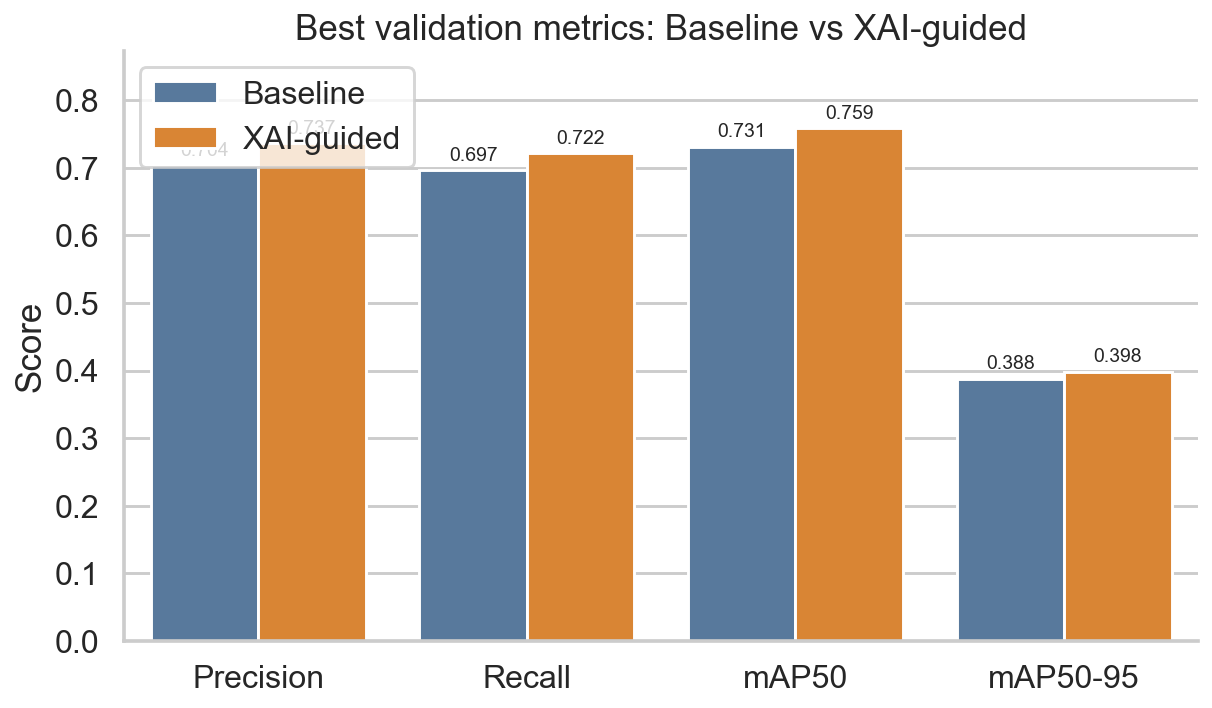

In [5]:

metric_labels = {
    "best_precision": "Precision",
    "best_recall": "Recall",
    "best_map50": "mAP50",
    "best_map50_95": "mAP50-95",
}
plot_df = summary_df[list(metric_labels)].rename(columns=metric_labels)
long_df = plot_df.reset_index().melt(id_vars="run", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(9, 5.4))
sns.barplot(data=long_df, x="metric", y="value", hue="run", palette=["#4C78A8", "#F58518"], ax=ax)
ax.set_xlabel(None)
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.8, long_df["value"].max() * 1.15))
ax.set_title("Best validation metrics: Baseline vs XAI-guided")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)
ax.legend(title=None, loc="upper left")
plt.tight_layout()
save_figure(fig, "main_metrics_bar")
plt.show()


## 3. Đường cong metric theo epoch

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/metric_curves_over_epochs.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/metric_curves_over_epochs.pdf


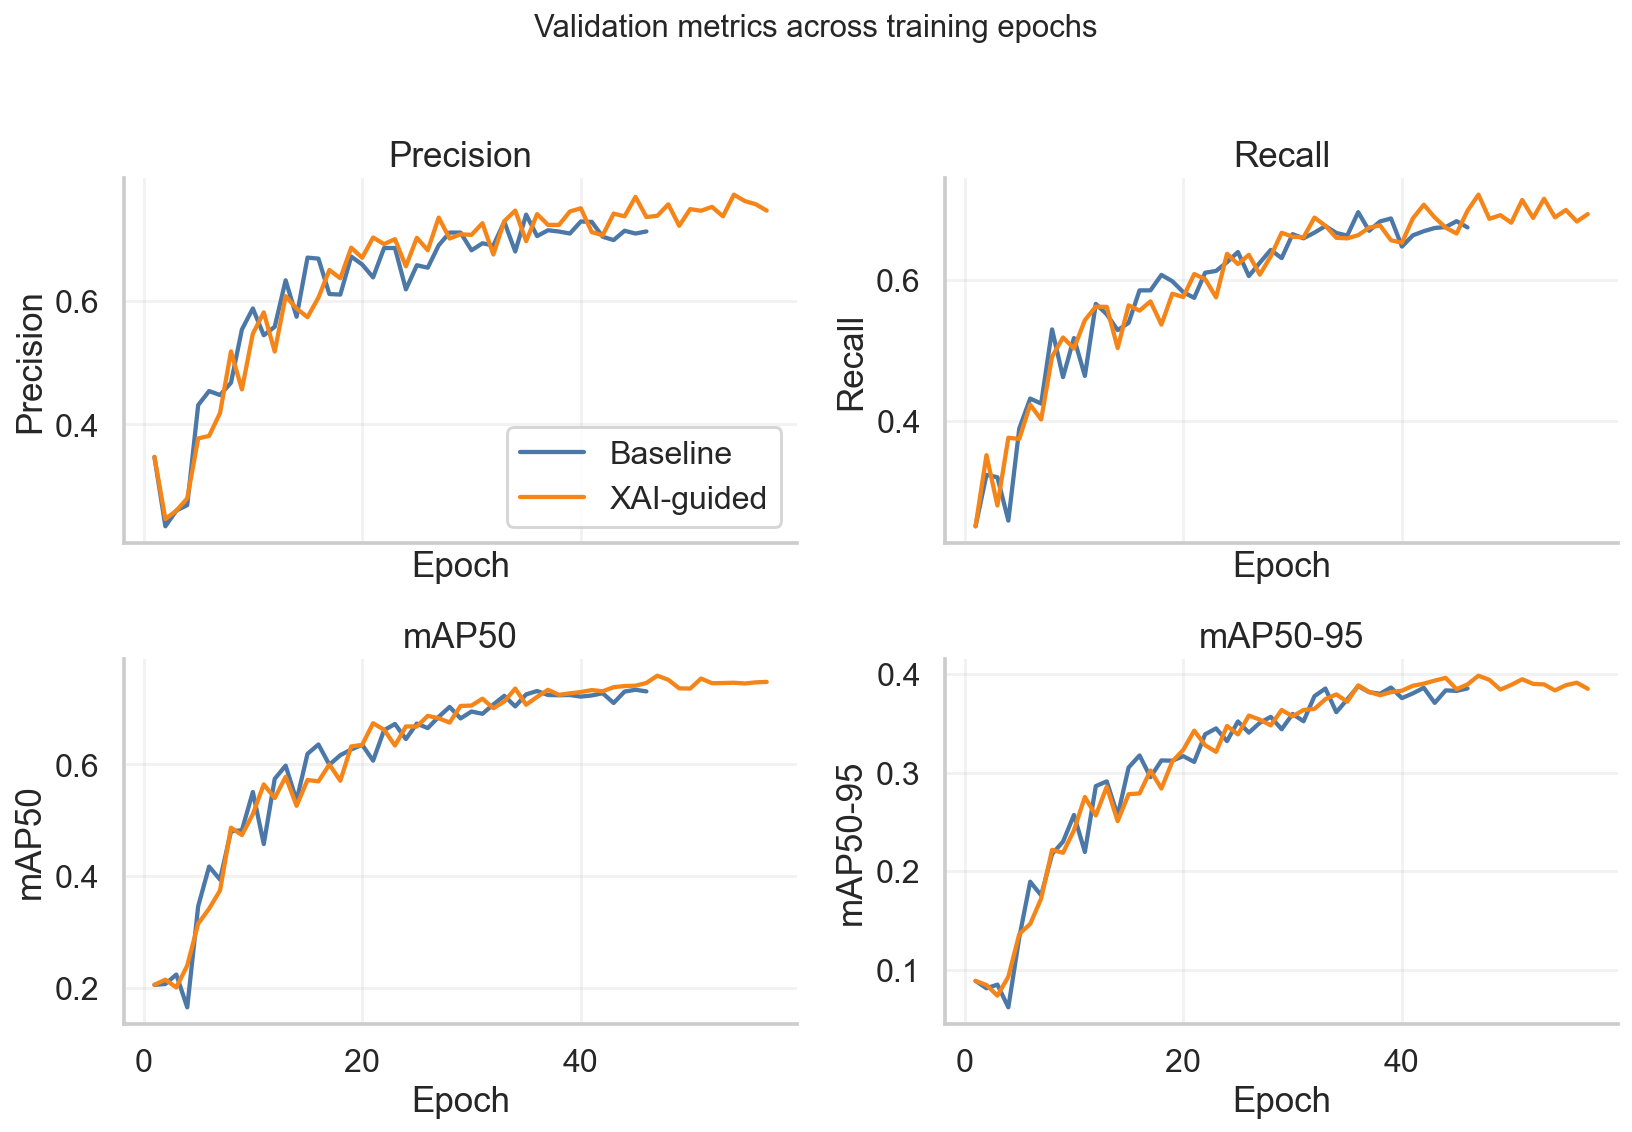

In [6]:

metric_pairs = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
    ("metrics/mAP50-95(B)", "mAP50-95"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (col, label) in zip(axes.flat, metric_pairs):
    ax.plot(baseline["history"]["epoch"], baseline["history"][col], label="Baseline", linewidth=2.2, color="#4C78A8")
    ax.plot(xai["history"]["epoch"], xai["history"][col], label="XAI-guided", linewidth=2.2, color="#F58518")
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.grid(alpha=0.25)

axes[0, 0].legend(frameon=True)
fig.suptitle("Validation metrics across training epochs", y=1.02, fontsize=16)
plt.tight_layout()
save_figure(fig, "metric_curves_over_epochs")
plt.show()


## 4. Loss và thời gian huấn luyện

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/loss_and_runtime_comparison.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/loss_and_runtime_comparison.pdf


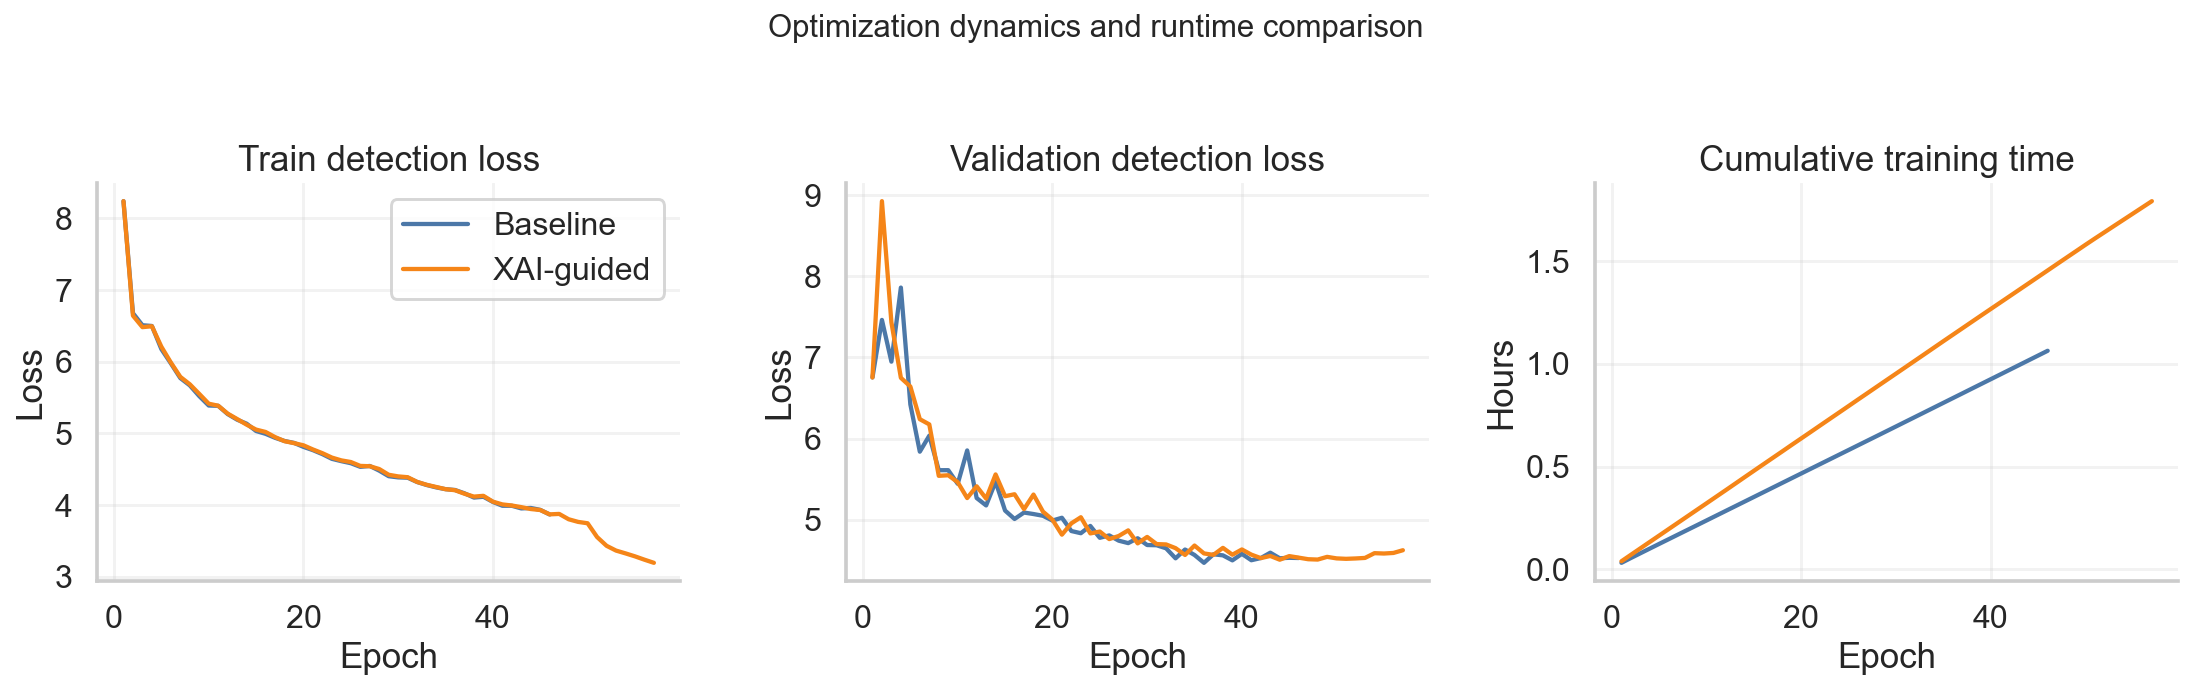

In [7]:

baseline_history = baseline["history"].copy()
xai_history = xai["history"].copy()

baseline_history["train_detection_loss"] = (
    baseline_history["train/box_loss"]
    + baseline_history["train/cls_loss"]
    + baseline_history["train/dfl_loss"]
)
baseline_history["val_detection_loss"] = (
    baseline_history["val/box_loss"]
    + baseline_history["val/cls_loss"]
    + baseline_history["val/dfl_loss"]
)

xai_history["train_detection_loss"] = (
    xai_history["train/box_loss"]
    + xai_history["train/cls_loss"]
    + xai_history["train/dfl_loss"]
)
xai_history["val_detection_loss"] = (
    xai_history["val/box_loss"]
    + xai_history["val/cls_loss"]
    + xai_history["val/dfl_loss"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(baseline_history["epoch"], baseline_history["train_detection_loss"], label="Baseline", linewidth=2.2, color="#4C78A8")
axes[0].plot(xai_history["epoch"], xai_history["train_detection_loss"], label="XAI-guided", linewidth=2.2, color="#F58518")
axes[0].set_title("Train detection loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=True)

axes[1].plot(baseline_history["epoch"], baseline_history["val_detection_loss"], linewidth=2.2, color="#4C78A8")
axes[1].plot(xai_history["epoch"], xai_history["val_detection_loss"], linewidth=2.2, color="#F58518")
axes[1].set_title("Validation detection loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

axes[2].plot(baseline_history["epoch"], baseline_history["time"] / 3600.0, linewidth=2.2, color="#4C78A8")
axes[2].plot(xai_history["epoch"], xai_history["time"] / 3600.0, linewidth=2.2, color="#F58518")
axes[2].set_title("Cumulative training time")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Hours")

for ax in axes:
    ax.grid(alpha=0.25)

fig.suptitle("Optimization dynamics and runtime comparison", y=1.04, fontsize=16)
plt.tight_layout()
save_figure(fig, "loss_and_runtime_comparison")
plt.show()


## 5. Chẩn đoán riêng của nhánh saliency

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/xai_saliency_diagnostics.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/xai_saliency_diagnostics.pdf


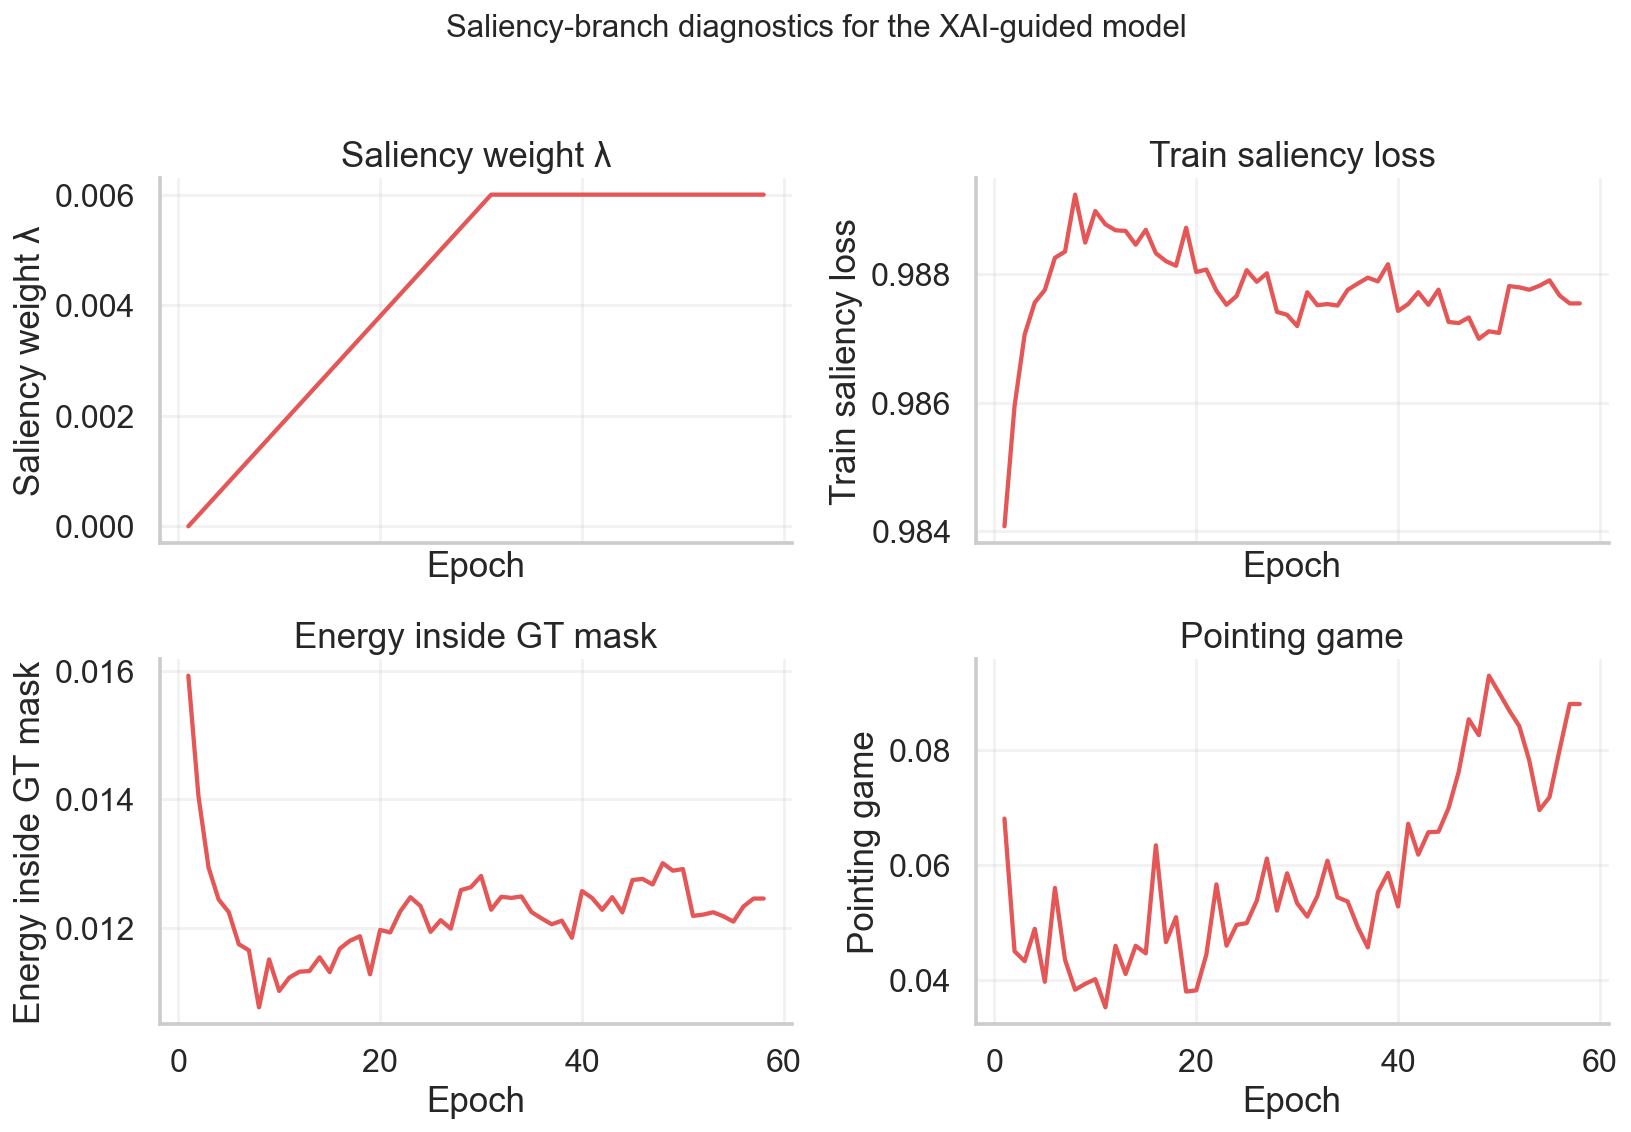

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metrics = [
    ("lambda_saliency", "Saliency weight λ"),
    ("train_saliency_loss", "Train saliency loss"),
    ("train_energy_in_box", "Energy inside GT mask"),
    ("train_pointing_game", "Pointing game"),
]
for ax, (col, title) in zip(axes.flat, metrics):
    ax.plot(xai_train_history["epoch"], xai_train_history[col], linewidth=2.2, color="#E45756")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.grid(alpha=0.25)

fig.suptitle("Saliency-branch diagnostics for the XAI-guided model", y=1.02, fontsize=16)
plt.tight_layout()
save_figure(fig, "xai_saliency_diagnostics")
plt.show()


## 6. Hiệu năng theo lớp của mô hình XAI-guided

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/xai_per_class_map50_95.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/xai_per_class_map50_95.pdf


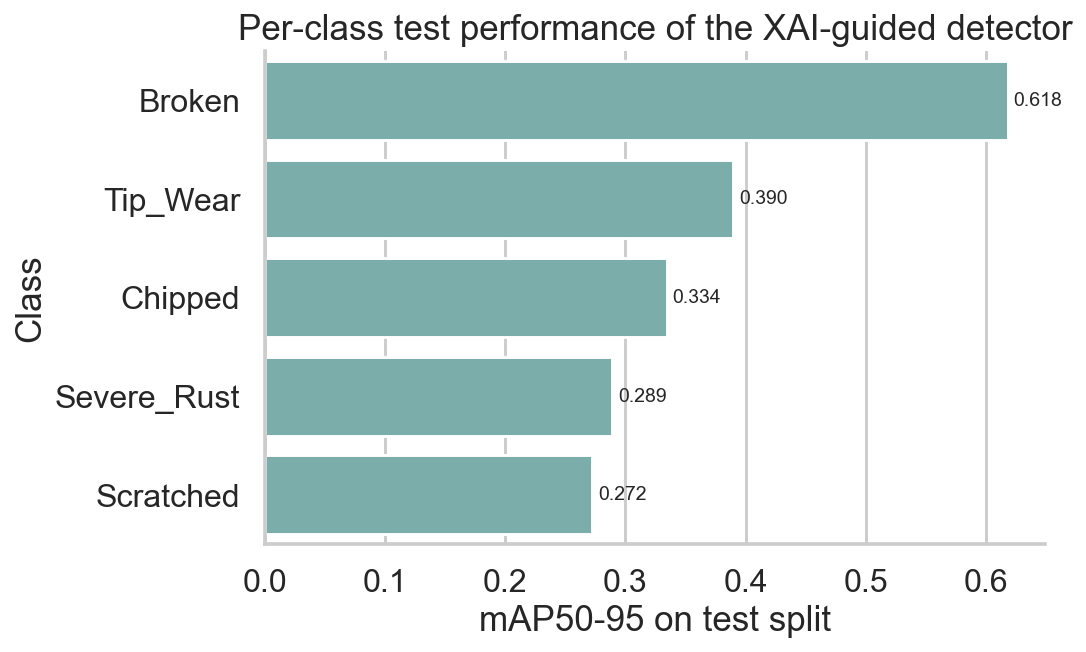

In [9]:

per_class = pd.DataFrame(
    list(xai_best_test["per_class_map50_95"].items()),
    columns=["class", "map50_95"],
)
per_class = per_class[per_class["class"] != "drill"].copy()
per_class = per_class.sort_values("map50_95", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=per_class, x="map50_95", y="class", color="#72B7B2", ax=ax)
ax.set_xlabel("mAP50-95 on test split")
ax.set_ylabel("Class")
ax.set_title("Per-class test performance of the XAI-guided detector")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)
plt.tight_layout()
save_figure(fig, "xai_per_class_map50_95")
plt.show()

## 7. Ghép các artifact tổng hợp sẵn có

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/artifact_panels.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/artifact_panels.pdf


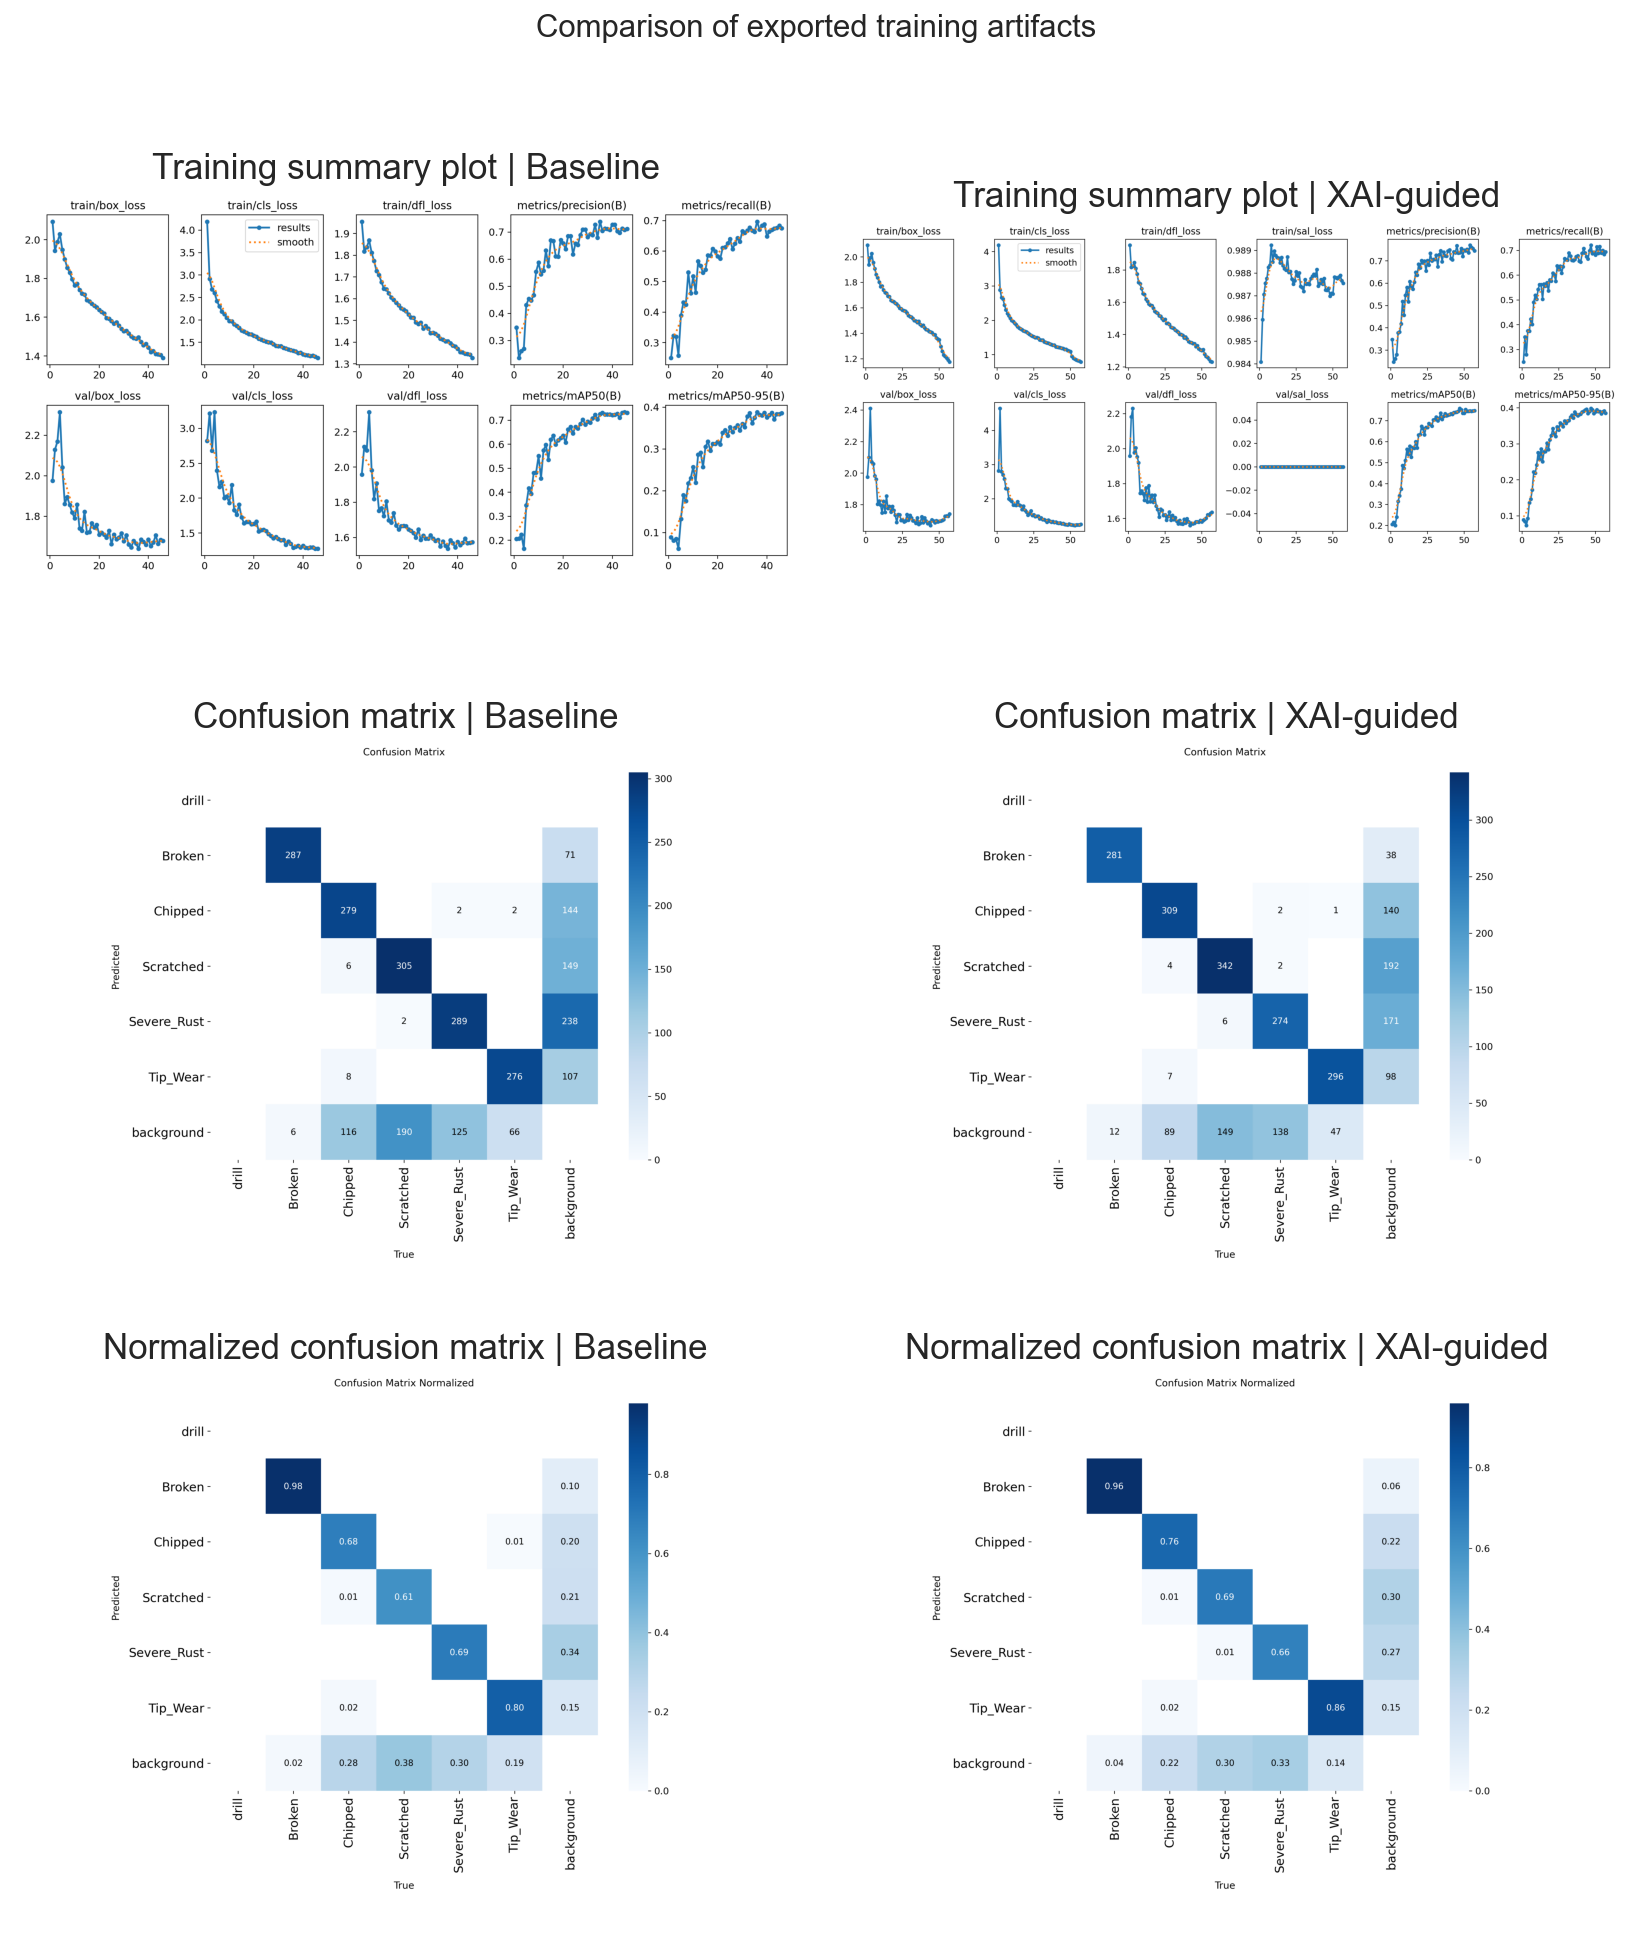

In [10]:

artifact_rows = [
    ("Training summary plot", BASELINE_DIR / "results.png", XAI_DIR / "results.png"),
    ("Confusion matrix", BASELINE_DIR / "confusion_matrix.png", XAI_DIR / "confusion_matrix.png"),
    ("Normalized confusion matrix", BASELINE_DIR / "confusion_matrix_normalized.png", XAI_DIR / "confusion_matrix_normalized.png"),
]

fig, axes = plt.subplots(len(artifact_rows), 2, figsize=(12, 14))
for row_idx, (title, baseline_path, xai_path) in enumerate(artifact_rows):
    for col_idx, (run_name, path) in enumerate([("Baseline", baseline_path), ("XAI-guided", xai_path)]):
        ax = axes[row_idx, col_idx]
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"{title} | {run_name}")
        ax.axis("off")

fig.suptitle("Comparison of exported training artifacts", y=0.995, fontsize=16)
plt.tight_layout()
save_figure(fig, "artifact_panels")
plt.show()


## 8. So sánh dự đoán trên các batch validation

Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/validation_prediction_panels.png
Saved: ../../output/compare_xai_vs_baseline_v2_fixed/figures/validation_prediction_panels.pdf


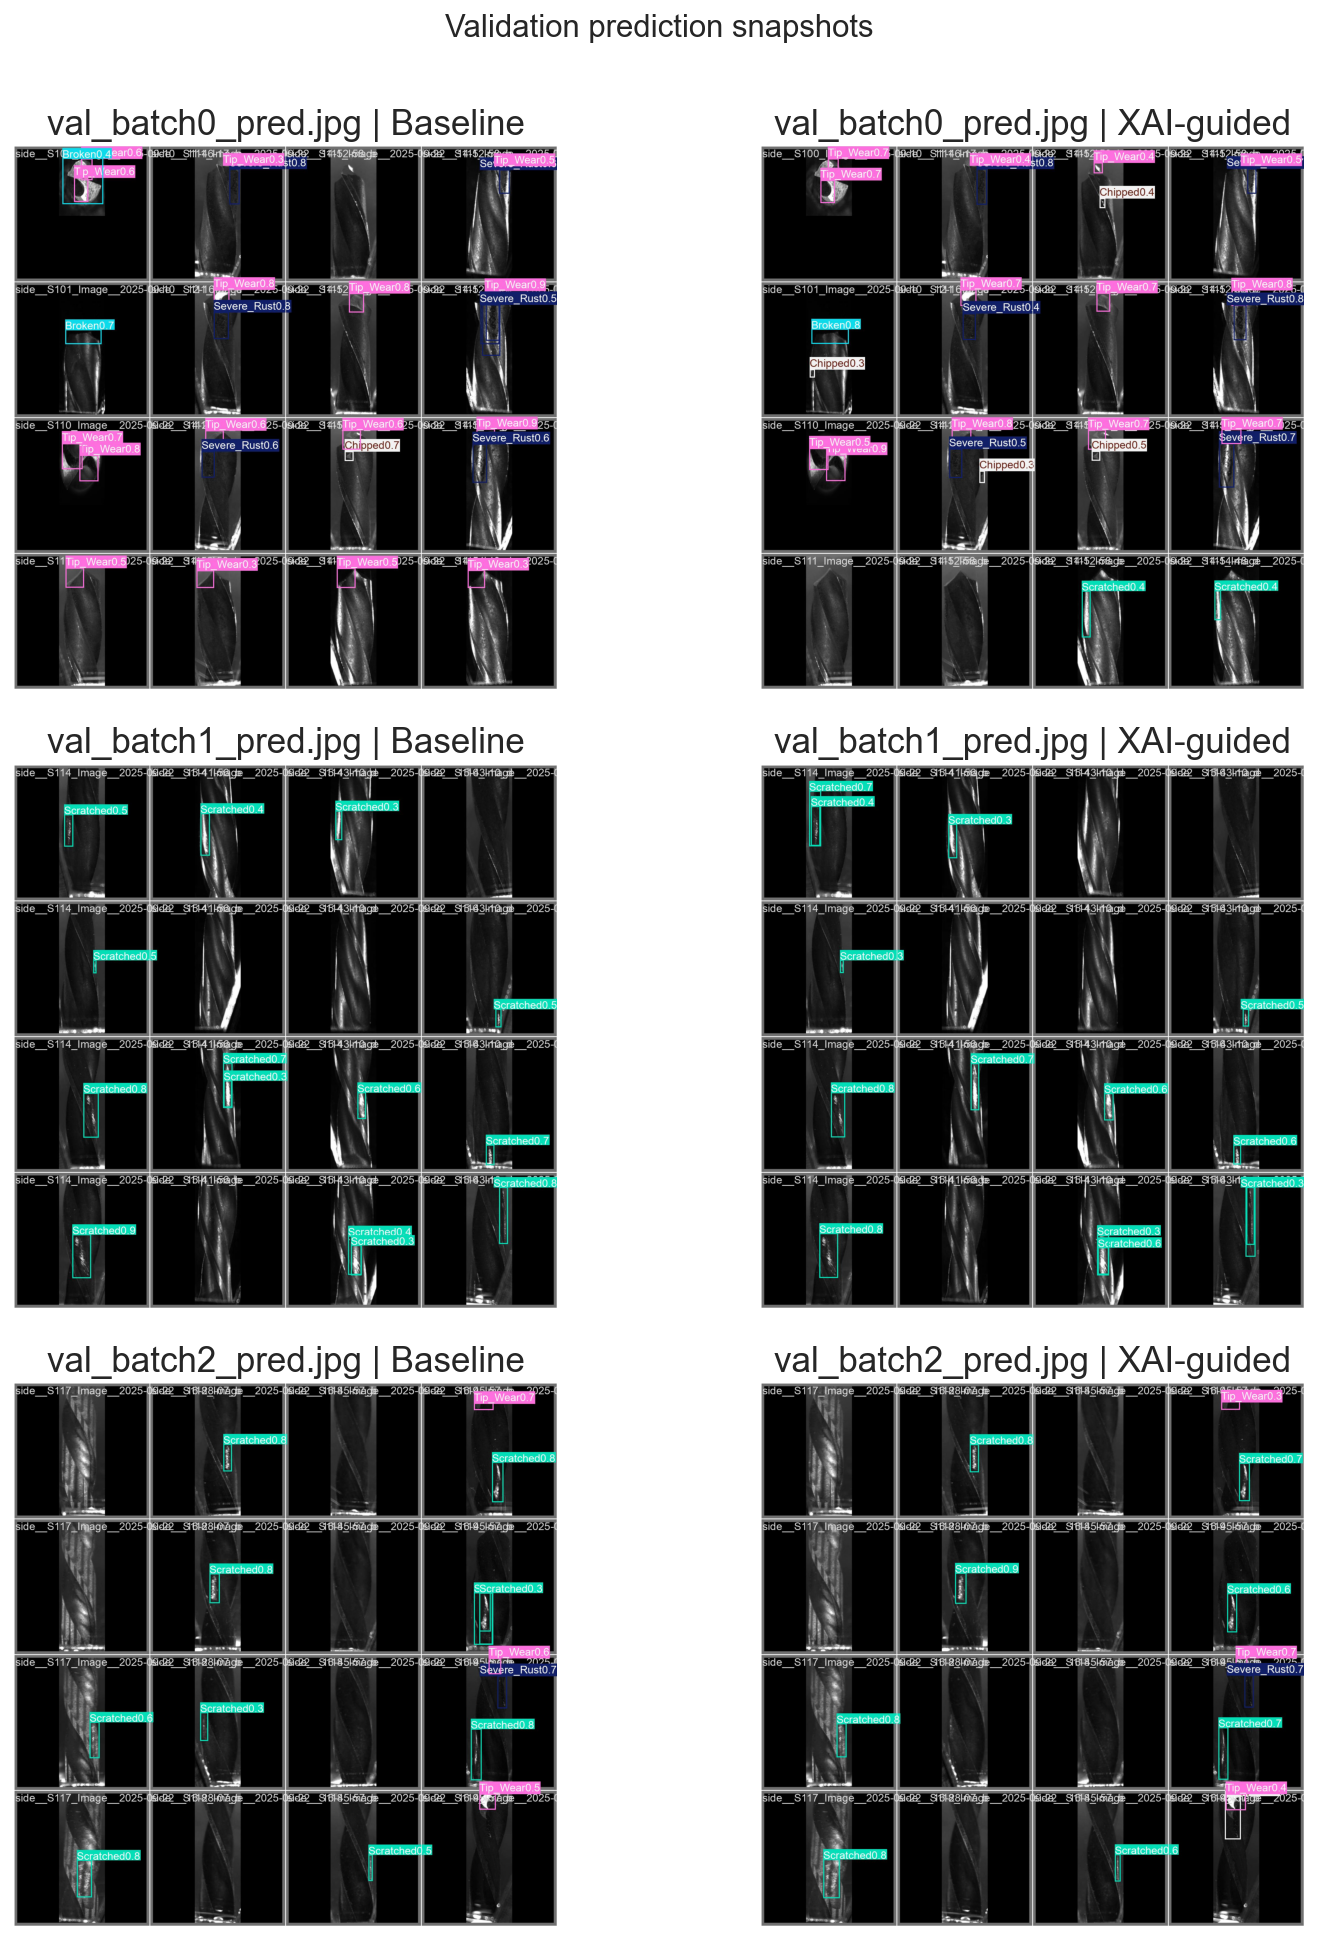

In [11]:

image_names = ["val_batch0_pred.jpg", "val_batch1_pred.jpg", "val_batch2_pred.jpg"]
fig, axes = plt.subplots(len(image_names), 2, figsize=(12, 14))
for row_idx, image_name in enumerate(image_names):
    for col_idx, (run_name, run_dir) in enumerate([("Baseline", BASELINE_DIR), ("XAI-guided", XAI_DIR)]):
        ax = axes[row_idx, col_idx]
        img_path = run_dir / image_name
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"{image_name} | {run_name}")
        ax.axis("off")

fig.suptitle("Validation prediction snapshots", y=0.995, fontsize=16)
plt.tight_layout()
save_figure(fig, "validation_prediction_panels")
plt.show()


## 9. Các tệp đã sinh

In [12]:

files = sorted(FIG_DIR.glob("*"))
display(Markdown("".join([f"- `{path.name}`" for path in files])))
print(f"Tong so tep trong {FIG_DIR}: {len(files)}")


- `artifact_panels.pdf`- `artifact_panels.png`- `loss_and_runtime_comparison.pdf`- `loss_and_runtime_comparison.png`- `main_metrics_bar.pdf`- `main_metrics_bar.png`- `metric_curves_over_epochs.pdf`- `metric_curves_over_epochs.png`- `validation_prediction_panels.pdf`- `validation_prediction_panels.png`- `xai_per_class_map50_95.pdf`- `xai_per_class_map50_95.png`- `xai_saliency_diagnostics.pdf`- `xai_saliency_diagnostics.png`

Tong so tep trong ../../output/compare_xai_vs_baseline_v2_fixed/figures: 14
